# Supplementary Figure: Threshold Analysis

This notebook generates a single visualization (two-panel figure) for threshold optimization and performance relationship using evaluation outputs from the model pipeline.

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score

FS_TITLE = 12
FS_SUBTITLE = 11
FS_LABEL = 12
FS_TICK = 11
FS_LEGEND = 10
FS_TEXT = 9

plt.style.use('default')
plt.rcParams.update({
    'font.size': FS_TEXT,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

base_dir = Path('/home/tobamo/analize/project-tobamo/analysis/model')
results_dir = base_dir / 'results'
figures_dir = base_dir / 'figures'
figures_dir.mkdir(exist_ok=True)

candidate_files = [
    results_dir / 'evaluation_results' / 'histogram_predictions_results.csv',
    results_dir / 'evaluation_results_tuned' / 'histogram_predictions_results.csv',
    results_dir / 'evaluation_results_fixed05' / 'stacking_predictions_results.csv',
    results_dir / 'evaluation_results_fixed05' / 'stacking_predictions_results_fixed_0p5.csv',
]

predictions_file = next((p for p in candidate_files if p.exists()), None)
if predictions_file is None:
    raise FileNotFoundError('No threshold prediction results CSV found in expected results folders.')

hpr = pd.read_csv(predictions_file)
threshold_stats = hpr.groupby(['iteration', 'fold_idx'])['threshold'].first().reset_index()

print(f'Loaded predictions from: {predictions_file}')
print(f'Total CV units (iteration x fold): {len(threshold_stats)}')
print(f"Threshold range: {threshold_stats['threshold'].min():.3f} - {threshold_stats['threshold'].max():.3f}")

Loaded predictions from: /home/tobamo/analize/project-tobamo/analysis/model/results/evaluation_results_tuned/histogram_predictions_results.csv
Total CV units (iteration x fold): 150
Threshold range: 0.374 - 0.687


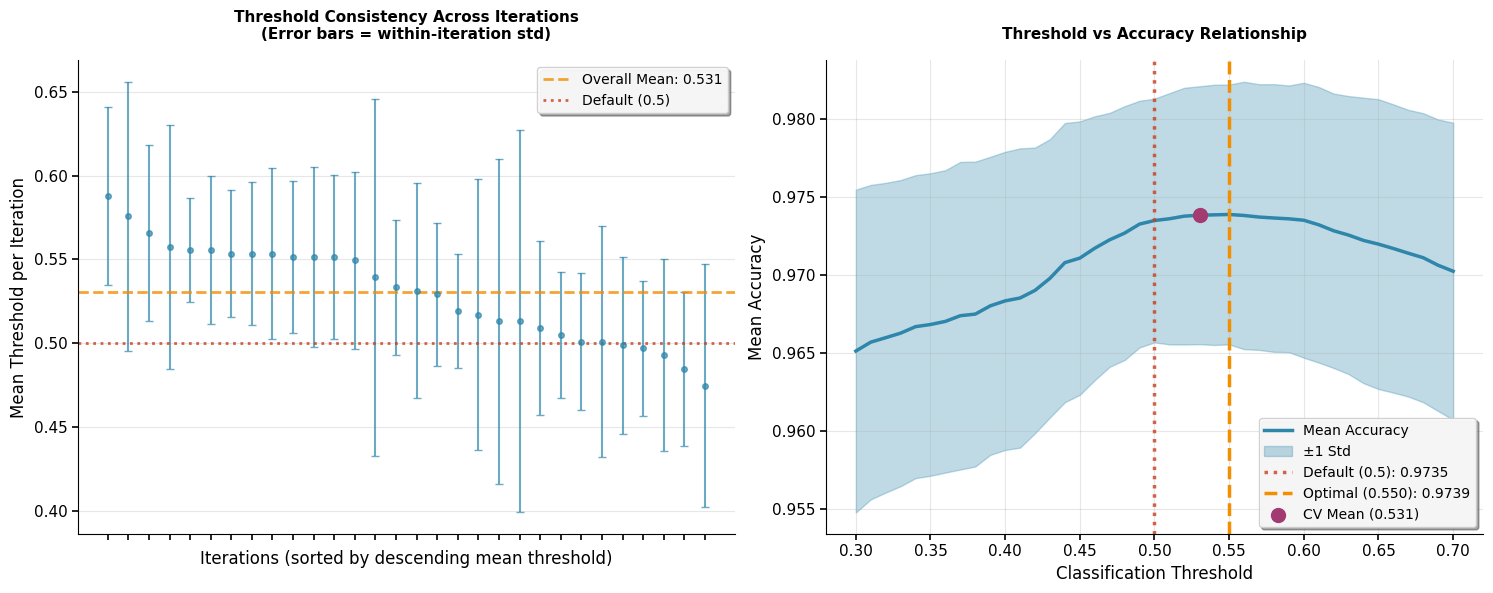

Saved figure to: /home/tobamo/analize/project-tobamo/analysis/model/figures/Figure_Supp5_ThresholdAnalysis_Optimization_Performance.png


In [4]:
# Threshold Analysis: Optimization and Performance Relationship (title removed by request)

# Panel 1: threshold consistency across iterations (sorted by descending mean threshold)
iteration_means = threshold_stats.groupby('iteration')['threshold'].mean()
iteration_stds = threshold_stats.groupby('iteration')['threshold'].std()
sorted_iterations = iteration_means.sort_values(ascending=False)
sorted_stds = iteration_stds.loc[sorted_iterations.index]
x_positions = np.arange(len(sorted_iterations))
mean_threshold = threshold_stats['threshold'].mean()

# Panel 2: threshold sweep and mean accuracy
threshold_acc_analysis = []
for threshold_val in np.linspace(0.3, 0.7, 41):
    fold_accuracies = []
    for _, fold_group in hpr.groupby(['iteration', 'fold_idx']):
        pred = (fold_group['prob_1'] >= threshold_val).astype(int)
        acc = accuracy_score(fold_group['ground_truth'], pred)
        fold_accuracies.append(acc)
    threshold_acc_analysis.append({
        'threshold': threshold_val,
        'mean_accuracy': np.mean(fold_accuracies),
        'std_accuracy': np.std(fold_accuracies),
    })

threshold_curve = pd.DataFrame(threshold_acc_analysis)
default_acc = threshold_curve.loc[threshold_curve['threshold'].round(3) == 0.5, 'mean_accuracy'].iloc[0]
optimal_idx = threshold_curve['mean_accuracy'].idxmax()
optimal_threshold = threshold_curve.loc[optimal_idx, 'threshold']
optimal_acc = threshold_curve.loc[optimal_idx, 'mean_accuracy']
closest_idx = np.abs(threshold_curve['threshold'] - mean_threshold).idxmin()
cv_mean_acc = threshold_curve.loc[closest_idx, 'mean_accuracy']

# Color palette consistent with source analysis
primary_color = '#2E86AB'
secondary_color = '#A23B72'
accent_color = '#F18F01'
neutral_color = '#C73E1D'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.errorbar(
    x_positions,
    sorted_iterations.values,
    yerr=sorted_stds.values,
    fmt='o',
    color=primary_color,
    ecolor=primary_color,
    alpha=0.7,
    capsize=3,
    capthick=1,
    markersize=4,
    linewidth=1.5,
 )
ax1.axhline(
    mean_threshold,
    color=accent_color,
    linestyle='--',
    linewidth=2,
    alpha=0.8,
    label=f'Overall Mean: {mean_threshold:.3f}',
 )
ax1.axhline(
    0.5,
    color=neutral_color,
    linestyle=':',
    linewidth=2,
    alpha=0.8,
    label='Default (0.5)',
 )
ax1.set_xticks(x_positions)
ax1.set_xticklabels([])
ax1.set_xlabel('Iterations (sorted by descending mean threshold)', fontsize=FS_LABEL)
ax1.set_ylabel('Mean Threshold per Iteration', fontsize=FS_LABEL)
ax1.set_title(
    'Threshold Consistency Across Iterations\n(Error bars = within-iteration std)',
    fontsize=FS_SUBTITLE,
    pad=15,
    fontweight='bold',
 )
ax1.legend(fontsize=FS_LEGEND, frameon=True, fancybox=True, shadow=True, framealpha=0.9)
ax1.grid(axis='y', alpha=0.3, linewidth=0.8)
ax1.tick_params(axis='both', which='major', labelsize=FS_TICK, width=1.2, length=4)

ax2.plot(
    threshold_curve['threshold'],
    threshold_curve['mean_accuracy'],
    color=primary_color,
    linewidth=2.5,
    label='Mean Accuracy',
 )
ax2.fill_between(
    threshold_curve['threshold'],
    threshold_curve['mean_accuracy'] - threshold_curve['std_accuracy'],
    threshold_curve['mean_accuracy'] + threshold_curve['std_accuracy'],
    alpha=0.3,
    color=primary_color,
    label='±1 Std',
 )
ax2.axvline(
    0.5,
    color=neutral_color,
    linestyle=':',
    linewidth=2.5,
    alpha=0.8,
    label=f'Default (0.5): {default_acc:.4f}',
 )
ax2.axvline(
    optimal_threshold,
    color=accent_color,
    linestyle='--',
    linewidth=2.5,
    label=f'Optimal ({optimal_threshold:.3f}): {optimal_acc:.4f}',
 )
ax2.scatter(
    [mean_threshold],
    [cv_mean_acc],
    color=secondary_color,
    s=100,
    zorder=5,
    label=f'CV Mean ({mean_threshold:.3f})',
 )
ax2.set_xlabel('Classification Threshold', fontsize=FS_LABEL)
ax2.set_ylabel('Mean Accuracy', fontsize=FS_LABEL)
ax2.set_title('Threshold vs Accuracy Relationship', fontsize=FS_SUBTITLE, pad=15, fontweight='bold')
ax2.legend(fontsize=FS_LEGEND, frameon=True, fancybox=True, shadow=True, framealpha=0.9)
ax2.grid(alpha=0.3, linewidth=0.8)
ax2.tick_params(axis='both', which='major', labelsize=FS_TICK, width=1.2, length=4)

plt.tight_layout()
output_path = figures_dir / 'Figure_Supp5_ThresholdAnalysis_Optimization_Performance.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()

print(f'Saved figure to: {output_path}')